# Download e visão inicial dos dados

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

In [2]:
symbol = 'MSFT'
start_date = '2024-01-01'
end_date = '2025-10-31'

df = yf.download(symbol, start=start_date, end=end_date)

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_1243/1067247225.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [3]:
print('df info:')
print(df.info)

print(f'is there any NaN?: {df.isnull().any().any()}')


df info:
<bound method DataFrame.info of Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  365.421570  370.377673  361.381797  368.367634  25258600
2024-01-03  365.155579  367.776505  363.096286  363.588941  23083500
2024-01-04  362.534668  367.618867  361.775991  365.224573  20901500
2024-01-05  362.347443  366.594123  361.115806  363.549521  21004600
2024-01-08  369.185516  369.688034  363.588967  363.874685  23134000
...                ...         ...         ...         ...       ...
2025-10-24  522.631836  524.368576  519.737290  521.813360  15532400
2025-10-27  530.527100  533.581381  528.021779  530.786624  18734700
2025-10-28  541.057373  552.685573  539.759814  548.972552  29986700
2025-10-29  540.538330  545.249544  535.727327  543.922012  36023000
2025-10-30  524.777832  533.970588  521.144617  529.488985  41

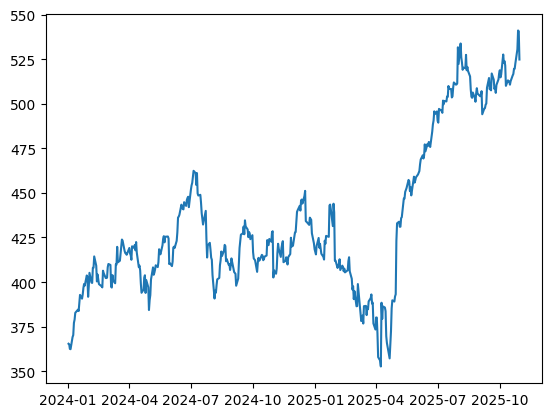

In [4]:
plt.plot(df['Close'])

In [5]:
print('df columns:')
print(df.columns)


df columns:
MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [6]:
# tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421570,370.377673,361.381797,368.367634,25258600
2024-01-03,365.155579,367.776505,363.096286,363.588941,23083500
2024-01-04,362.534668,367.618867,361.775991,365.224573,20901500
2024-01-05,362.347443,366.594123,361.115806,363.549521,21004600
2024-01-08,369.185516,369.688034,363.588967,363.874685,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,530.786624,18734700
2025-10-28,541.057373,552.685573,539.759814,548.972552,29986700


# Tratando outliers

In [7]:
# Criando função para tratar outliers

def cap_outliers(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        print(f'{col} limits: lower: {lower} upper: {upper}')

        df[col] = df[col].clip(lower, upper) #Valores menores que lower são substituídos por lower. Valores maiores que upper são substituídos por upper. Mantém o tamanho do DataFrame → essencial para LSTM. Evita excluir linhas e quebrar a sequência temporal.
    return df


In [8]:
df_sem_outliers = cap_outliers(df, df.columns)

Close limits: lower: 330.4283447265625 upper: 530.8385620117188
High limits: lower: 333.79196442857597 upper: 533.8218466112467
Low limits: lower: 325.9742267445313 upper: 528.8090683716202
Open limits: lower: 331.7281753469312 upper: 527.5596506498871
Volume limits: lower: 5844875.0 upper: 33769275.0


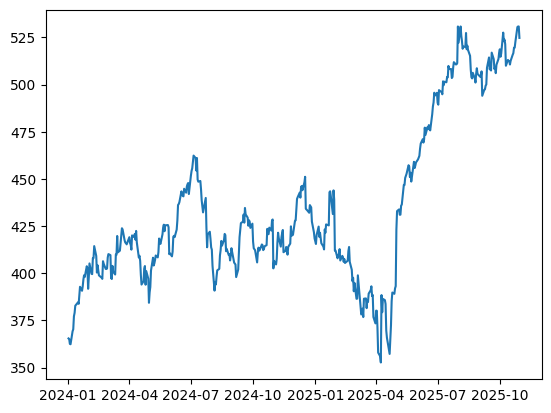

In [13]:
plt.plot(df_sem_outliers['Close'])